In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Helvetica Neue'

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
import config
import importlib
import spk_feat_cluster_comp_analysis as sfca
importlib.reload(sfca)
from spk_feat_cluster_comp_analysis import (
    kde_panel_solid,
    plot_isi_independence_legend,
    plot_isi_independence_example,
    plot_eta2_population,
    plot_eta2_legend,
)

CLUSTER_PKL_DIR = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/cluster_pickles/'

# Wong (2011) 2-group palette: low=blue, high=vermillion
CLUST_COLORS = {'low': '#0072B2', 'high': '#D55E00'}
EXAMPLE_CELL = 32

FEATS = [
    ('peak_amp',       'Peak\namplitude',         False),
    ('peak_sharpness', 'Peak\nsharpness',          False),
    ('exp_const',      'Repolarization\nconstant', False),
    ('log_isi',        'Log ISI',                  True),
]

Supplementary Figure X. Spike waveform clusters are independent of ISI-based clusters.

(A) Feature distributions for an example cell (c32, n = 2887 spikes), shown as solid-fill kernel density estimates (IQR × 3 outlier removal, Scott's rule bandwidth, proportional normalization). Row 1: spikes colored by peak amplitude cluster assignment (low cluster, blue; high cluster, orange). Waveform features (peak amplitude, peak sharpness, repolarization constant) are clearly separated between cluster groups; log inter-spike interval (log ISI; grey background) is not. Row 2: same spikes colored by ISI cluster assignment. Log ISI is clearly separated; waveform features are not.

(B) Population distribution of η² (Kruskal-Wallis H / (n − 1)) quantifying the association between waveform cluster assignment and log ISI across all cells with at least one waveform cluster and an ISI cluster (n = XX cells). Dashed line: population median. Dotted line: c32. η² near 0 indicates that waveform cluster membership does not explain ISI variability.

In [2]:
# ── Load cluster pickles ──────────────────────────────────────────────────────
NO_CLUSTER = [17, 18, 43]

cell_dfs = {}
for cnum in list(config.DICT_CELL_TYPE.keys()):
    if cnum in NO_CLUSTER:
        continue
    pkl = os.path.join(CLUSTER_PKL_DIR, f'c{cnum}_cluster_df.pkl')
    if not os.path.exists(pkl):
        continue
    df = pd.read_pickle(pkl)
    if 'log_isi' not in df.columns:
        continue
    # Accept any cell with at least one waveform cluster column
    wf_cols = [c for c in df.columns if c.endswith('_cluster') and c != 'log_isi_cluster']
    if not wf_cols and 'groups' not in df.columns:
        continue
    cell_dfs[cnum] = df

print(f'Cells loaded: {len(cell_dfs)}')

df_ex  = cell_dfs[EXAMPLE_CELL]
wclust = 'peak_amp_cluster' if 'peak_amp_cluster' in df_ex.columns else 'groups'
iclust = 'log_isi_cluster'
print(f'c{EXAMPLE_CELL}: wclust={wclust}, iclust={iclust}')

Cells loaded: 34
c32: wclust=peak_amp_cluster, iclust=log_isi_cluster


In [3]:
# ── Population η²: log ISI ~ waveform cluster (any waveform cluster) ──────────
from scipy.stats import kruskal

results = []
for cnum, df in cell_dfs.items():
    sub = df.dropna(subset=['log_isi'])
    # Use groups if present, otherwise first available waveform cluster column
    if 'groups' in sub.columns:
        wcol = 'groups'
    else:
        wf_cols = [c for c in sub.columns if c.endswith('_cluster') and c != 'log_isi_cluster']
        wcol = wf_cols[0] if wf_cols else None
    if wcol is None:
        continue
    sub    = sub.dropna(subset=[wcol])
    groups = [g for g in sub[wcol].unique() if len(sub[sub[wcol] == g]) >= 2]
    if len(groups) < 2:
        continue
    grp_data = [sub.loc[sub[wcol] == g, 'log_isi'].values for g in groups]
    n        = sum(len(g) for g in grp_data)
    H, _     = kruskal(*grp_data)
    results.append({'cell': cnum, 'waveform_cluster_col': wcol, 'eta2': H / (n - 1), 'n': n})

df_eta = pd.DataFrame(results).sort_values('cell').reset_index(drop=True)
print(f'n cells: {len(df_eta)}   Median η² = {df_eta.eta2.median():.3f}')
print(f'c{EXAMPLE_CELL} η² = {df_eta.loc[df_eta.cell == EXAMPLE_CELL, "eta2"].values[0]:.3f}')
print(df_eta[['cell', 'waveform_cluster_col', 'eta2']].to_string())

n cells: 33   Median η² = 0.013
c32 η² = 0.016
    cell     waveform_cluster_col      eta2
0      1         peak_amp_cluster  0.075262
1      2       exp_lambda_cluster  0.000041
2      3         peak_amp_cluster  0.071476
3      4         peak_amp_cluster  0.043381
4      5  inflection_time_cluster  0.000383
5      6       peak_width_cluster  0.012682
6      7  inflection_time_cluster  0.045501
7      8       peak_width_cluster  0.016794
8     10         peak_amp_cluster  0.005049
9     12       peak_width_cluster  0.000124
10    14   peak_sharpness_cluster  0.013487
11    15       peak_width_cluster  0.000493
12    19   peak_sharpness_cluster  0.001846
13    20         peak_amp_cluster  0.029970
14    21         peak_amp_cluster  0.030783
15    22  inflection_time_cluster  0.020563
16    23       peak_width_cluster  0.048969
17    24       peak_width_cluster  0.007507
18    25  inflection_time_cluster  0.056847
19    27   inflection_amp_cluster  0.006183
20    28       peak_width_clu

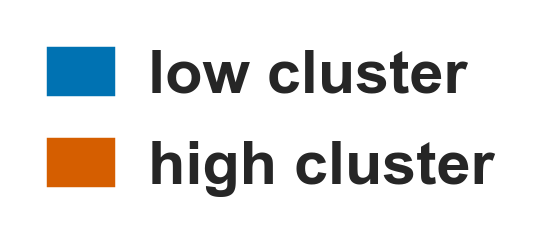

In [4]:
# ── Legend (separate) ─────────────────────────────────────────────────────────
fig_leg = plot_isi_independence_legend(CLUST_COLORS, fontsize=22)
plt.show()

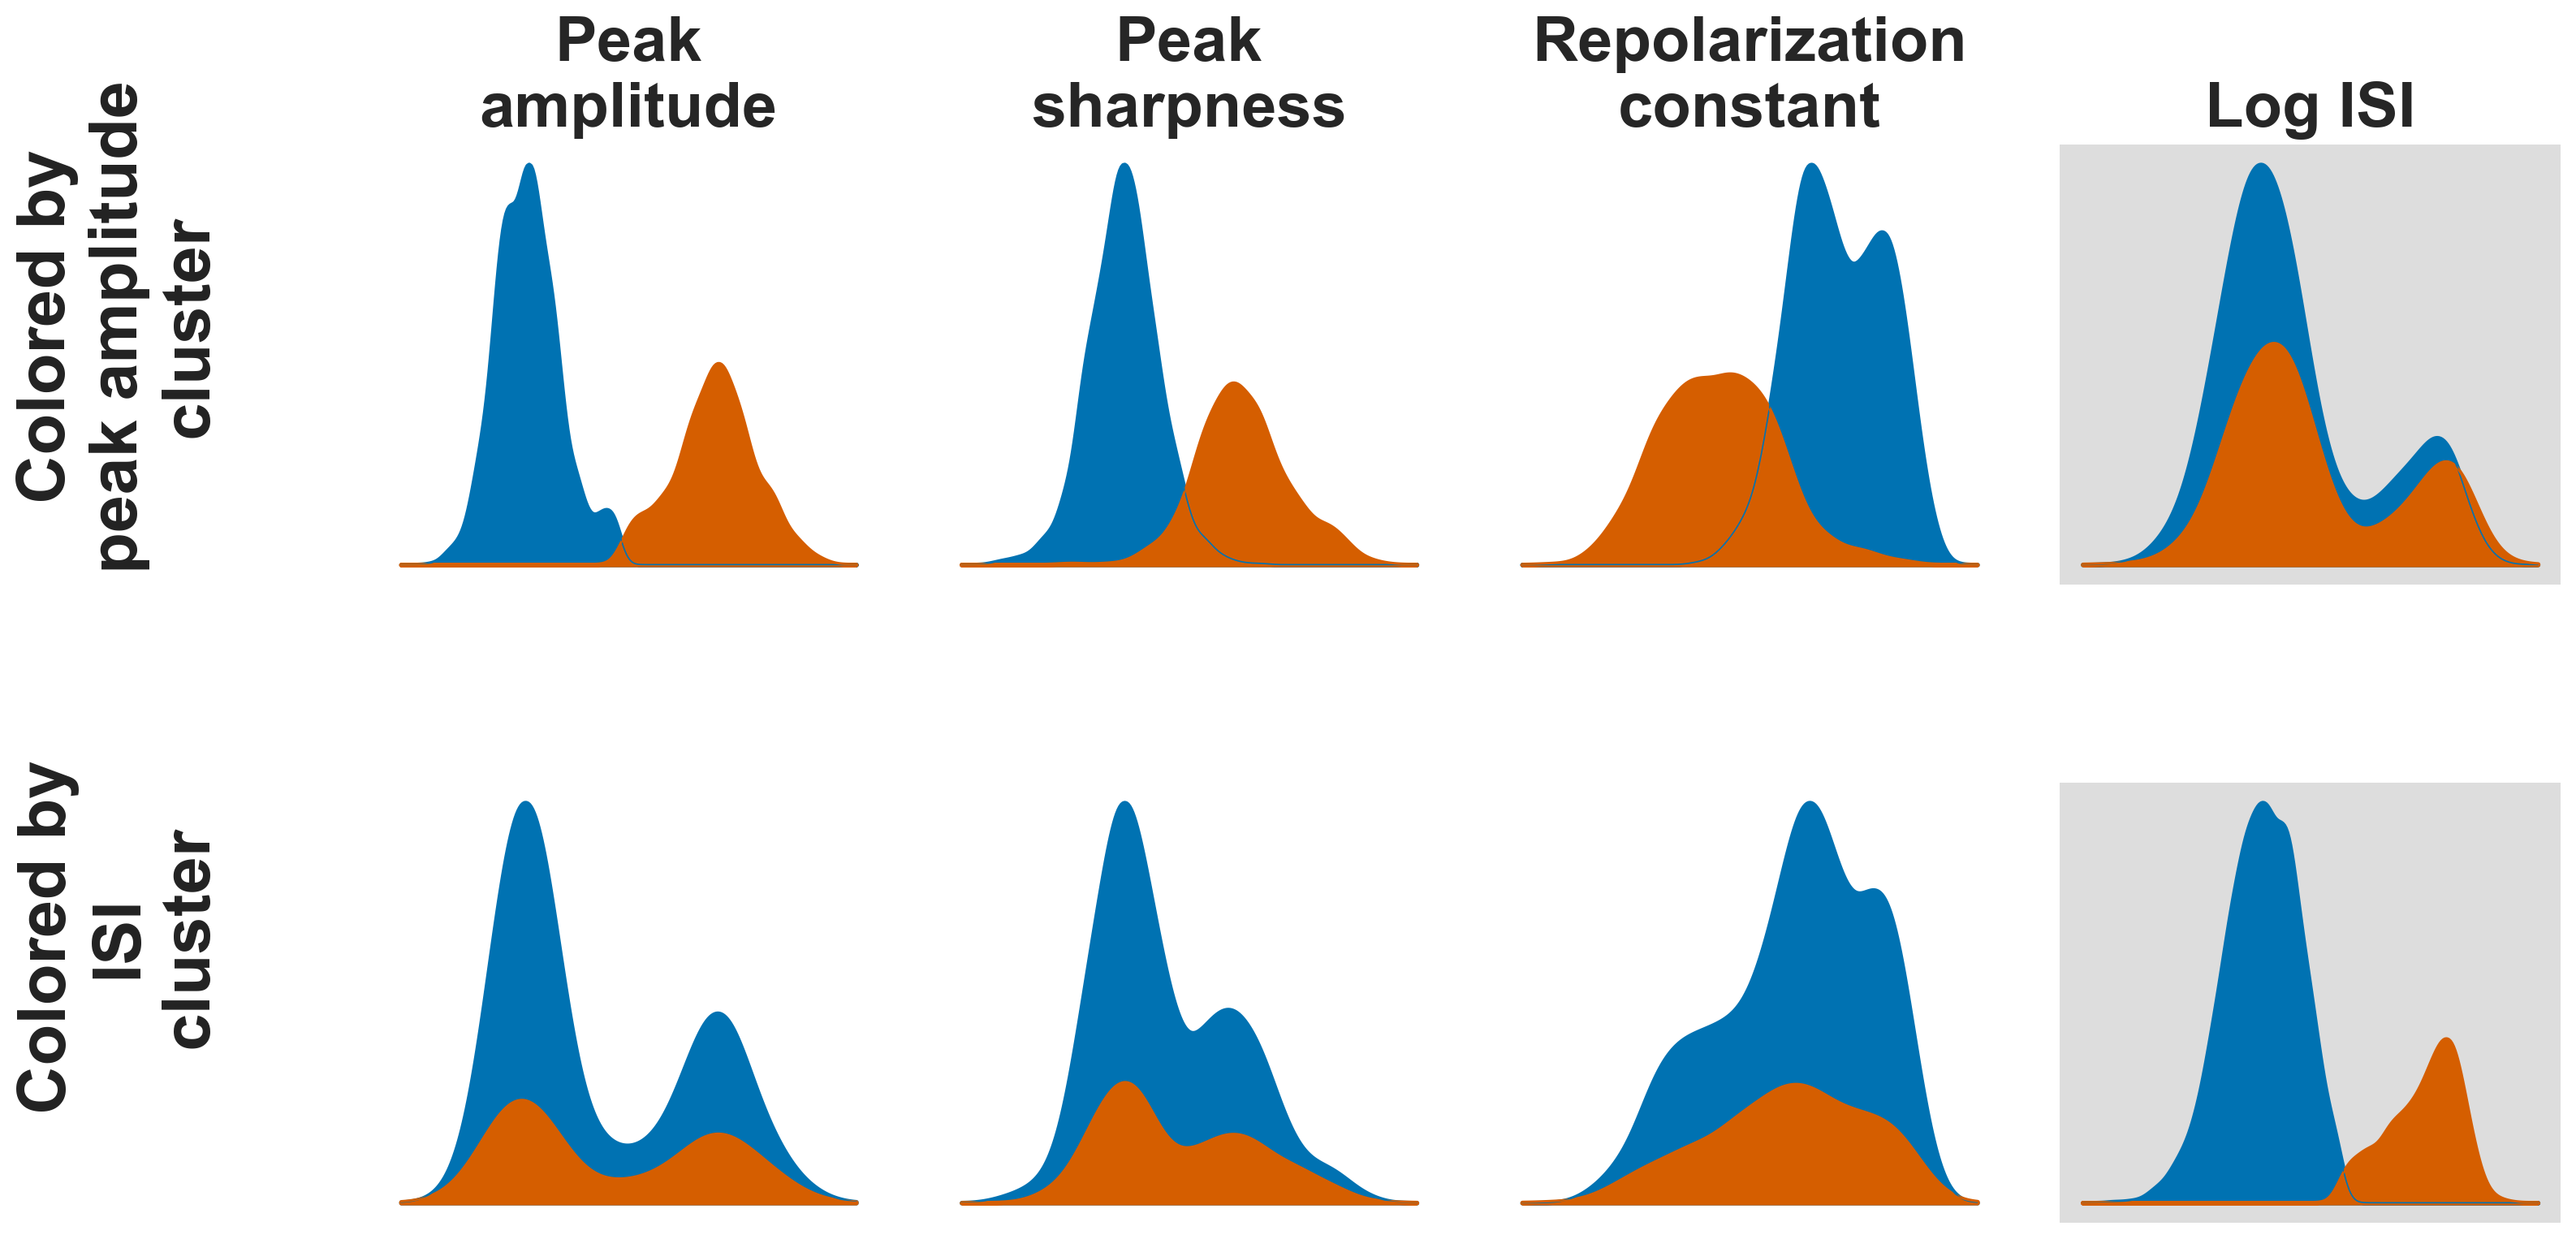

In [5]:
# ── c32 example: waveform vs ISI cluster ──────────────────────────────────────
fig_ex = plot_isi_independence_example(
    df_ex, wclust, iclust, FEATS, CLUST_COLORS,
    col_label_fs=28, row_label_fs=30,
    figsize=(16, 8),
)
plt.show()

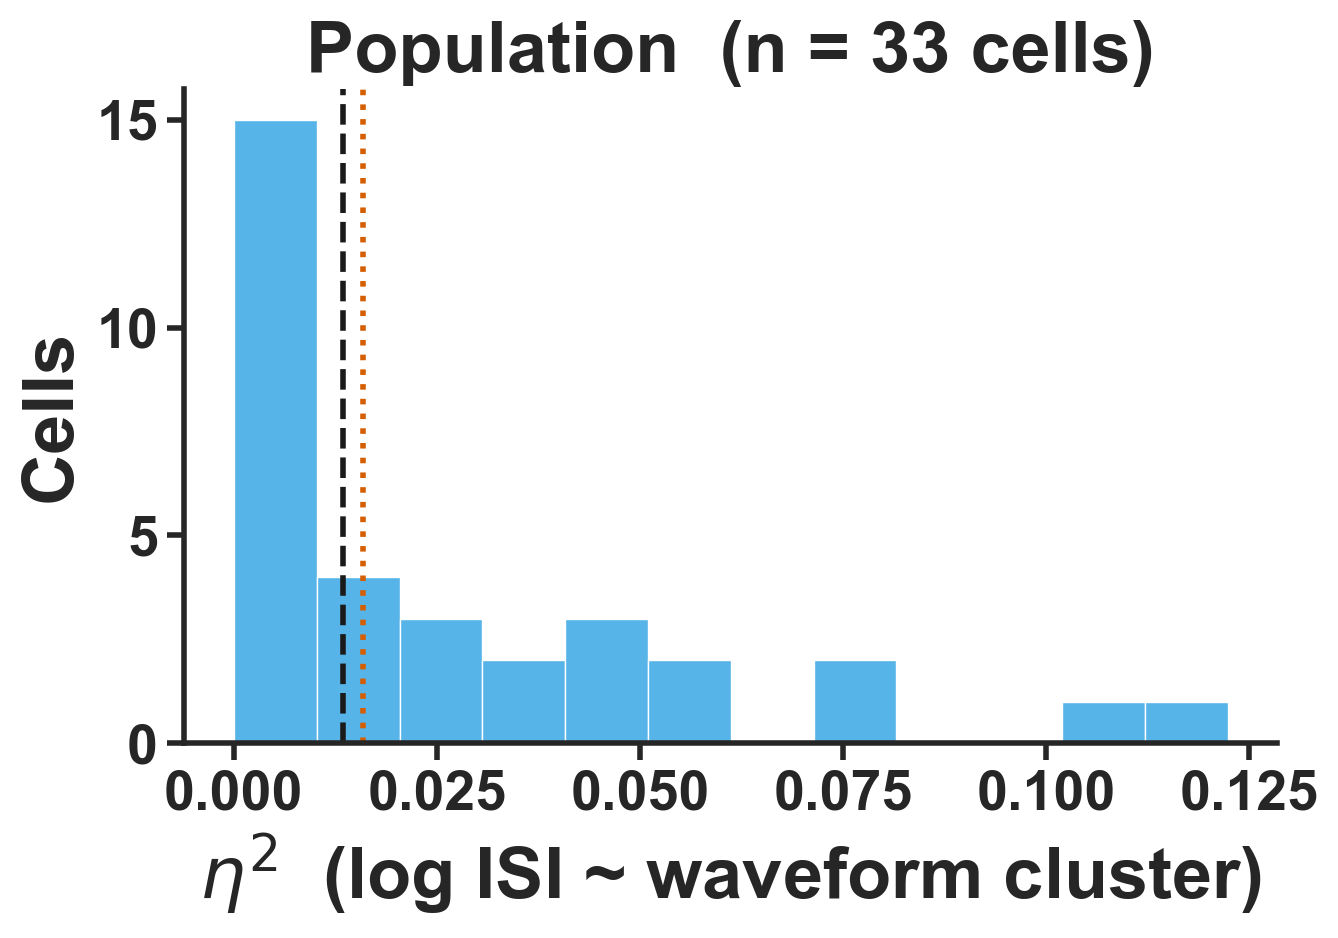

In [6]:
# ── Population η² histogram ───────────────────────────────────────────────────
fig_pop, med_eta2, ex_eta2 = plot_eta2_population(
    df_eta, EXAMPLE_CELL, CLUST_COLORS,
    fs_ax=26, fs_tk=20, lw_sp=2.0,
    figsize=(7, 5),
)
plt.show()

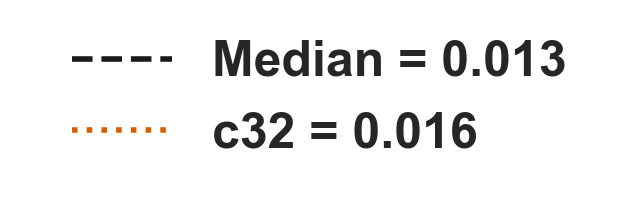

In [7]:
# ── Population legend (separate) ──────────────────────────────────────────────
fig_pop_leg = plot_eta2_legend(med_eta2, ex_eta2, EXAMPLE_CELL, CLUST_COLORS, fontsize=18)
plt.show()